In [ ]:
# -----------------------------------------------------------------------------
# ARTICLE 10 – PROPRIETE INTELLECTUELLE & LICENSE HEADER
# -----------------------------------------------------------------------------
# The present code is developed during a contest called « HI!CKATHON » organized
# at the request of HEC Paris and Institut Polytechnique de Paris, in the
# context of the Hi ! PARIS Center.
#
# License: LGPL v3 (Open Source)
# Authors: GROUP 26 - Gabin BIGARÉ, Antoine LOUVET, Rémi MALAPERT, Othmane NAMMOUS,
#          Valentin SENAUX et Tharushan UTHAYAKUMAR 
# -----------------------------------------------------------------------------

In [1]:
import numpy as np
import pylab as pl
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import pandas as pd
import seaborn as sns

#ML models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor

#Metrics
from sklearn.metrics import r2_score,mean_squared_error

#Selection
from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from tqdm.notebook import tqdm
import warnings
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

In [2]:

X_train = pd.read_csv('X_train.csv', low_memory=False)
y_train = pd.read_csv('y_train.csv')

print(f"Dimensions X_train: {X_train.shape}")
print(f"Dimensions y_train: {y_train.shape}")

display(X_train.head())

display(y_train.head())

missing_values = X_train.isnull().sum().sort_values(ascending=False)

display(y_train.describe())

target_col = y_train.columns[0] if len(y_train.columns) == 1 else y_train.columns[-1] 

Dimensions X_train: (1172086, 307)
Dimensions y_train: (1172086, 2)


,Unnamed: 0,Year,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,...,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
0,384002,2022,NLD,528.0,52800132.0,52801144.0,08MS,52800,NLD06,5280000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1118072,2018,QAZ,31.0,3100106.0,3100424.0,07MS,3100,QAZ0101,310000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,845454,2018,FRA,250.0,25000010.0,25005207.0,07MS,25000,FRA0101,2500000,...,87686.5,13164.75,1187.199951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1728613,2015,QES,971.0,97100240.0,97127584.0,06MS,72400,ESP1633,7241600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1083243,2018,PHL,608.0,60800071.0,60802698.0,07MS,60800,PHL0011,6080000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Unnamed: 0,MathScore
0,384002,116.975422
1,1118072,73.387560
2,845454,0.000000
3,1728613,0.000000
4,1083243,113.750718


,Unnamed: 0,MathScore
count,1.172086e+06,1.172086e+06
mean,8.788127e+05,9.999513e+01
std,5.075340e+05,1.221761e+02
min,0.000000e+00,0.000000e+00
25%,4.390612e+05,0.000000e+00
50%,8.787835e+05,6.604880e+01
75%,1.318404e+06,1.528073e+02
max,1.758128e+06,8.149725e+02


In [3]:
nan_y = y_train.isnull().sum().sum()

missing_percentage = (X_train.isnull().sum() / len(X_train)) * 100

missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

In [4]:

X_test = pd.read_csv('X_test.csv', low_memory=False)

print(f"Dimensions X_test: {X_test.shape}")

display(X_test.head())

missing_values = X_test.isnull().sum().sort_values(ascending=False)
print(missing_values.head(10))

Dimensions X_test: (586044, 307)


,Unnamed: 0,Year,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,...,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
0,412660,2022,PER,604.0,60400217.0,60404519.0,08MS,60400,PER03,6040000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,554658,2022,ARE,784.0,78400570.0,78413993.0,08MS,78401,ARE41,7840000,...,182597.5,271476.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,937138,2018,JOR,400.0,40000074.0,40001505.0,07MS,40000,JOR9797,4000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,752986,2018,CHL,152.0,15200099.0,15204046.0,07MS,15200,CHL0203,1520000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1084508,2018,PHL,608.0,60800098.0,60801563.0,07MS,60800,PHL0002,6080000,...,11491.5,31846.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


math_q4_average_score     586044
math_q11_average_score    586044
math_q9_total_timing      586044
math_q8_total_timing      586044
math_q7_total_timing      586044
math_q6_total_timing      586044
math_q5_total_timing      586044
math_q4_total_timing      586044
math_q3_total_timing      586044
math_q2_total_timing      586044
dtype: int64


In [5]:
def compare_nan_percentage(df_train, df_test):
    
    train_pct = (df_train.isnull().sum() / len(df_train)) * 100
    test_pct = (df_test.isnull().sum() / len(df_test)) * 100
    
    comparison_df = pd.DataFrame([train_pct, test_pct], index=['X_train', 'X_test'])
    
    cols_with_nan = comparison_df.columns[(comparison_df.sum() > 0)]
    comparison_df = comparison_df[cols_with_nan]
    
    return comparison_df

nan_comparison = compare_nan_percentage(X_train, X_test)
display(nan_comparison)

,LANGTEST_QQQ,LANGTEST_PAQ,Option_CT,Option_FL,Option_ICTQ,Option_WBQ,Option_PQ,Option_TQ,Option_UH,ST003D02T,...,science_q10_total_timing,science_q11_total_timing,science_q12_total_timing,science_q13_total_timing,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing
X_train,1.310313,83.768768,64.793795,35.092988,35.092988,64.793795,35.092988,35.092988,35.092988,2.704750,...,71.782446,81.050367,96.148320,99.999915,99.999915,99.999915,99.999915,99.999915,99.999915,99.999915
X_test,1.313553,83.804288,64.840012,35.132004,35.132004,64.840012,35.132004,35.132004,35.132004,2.699797,...,71.877538,81.102443,96.175884,99.999829,99.999829,99.999829,99.999829,99.999829,99.999829,99.999829


In [6]:
diff = (nan_comparison.loc['X_train'] - nan_comparison.loc['X_test']).abs()

diff_sorted = diff.sort_values(ascending=False)

display(diff_sorted.head(50))

display(nan_comparison[diff_sorted.head(50).index])

math_q1_average_score        62.771418
math_q2_average_score        62.610082
math_q3_average_score        62.334163
math_q4_average_score        61.419128
math_q5_average_score        60.047727
math_q6_average_score        58.175680
math_q2_total_timing         57.907952
math_q3_total_timing         57.801475
math_q4_total_timing         57.261071
math_q7_average_score        56.665637
math_q5_total_timing         56.172243
math_q6_total_timing         54.729346
math_q8_average_score        54.078711
math_q7_total_timing         53.807400
math_q8_total_timing         51.929125
math_q9_average_score        51.707895
math_q9_total_timing         50.072606
math_q10_average_score       45.300004
math_q10_total_timing        44.240098
math_q11_average_score       37.774703
math_q11_total_timing        37.609868
math_q12_total_timing        25.920538
math_q12_average_score       25.906205
math_q13_total_timing        15.569506
math_q13_average_score       15.312358
math_q14_total_timing    

,math_q1_average_score,math_q2_average_score,math_q3_average_score,math_q4_average_score,math_q5_average_score,math_q6_average_score,math_q2_total_timing,math_q3_total_timing,math_q4_total_timing,math_q7_average_score,...,science_q4_average_score,science_q6_total_timing,science_q5_average_score,science_q10_total_timing,science_q9_total_timing,science_q6_average_score,science_q9_average_score,science_q11_average_score,science_q8_total_timing,reading_q3_total_timing
X_train,37.228582,37.389918,37.665837,38.580872,39.952273,41.82432,42.092048,42.198525,42.738929,43.334363,...,39.439683,47.866539,40.486449,71.782446,62.188184,42.293142,59.634191,80.949777,52.617043,44.105808
X_test,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,...,39.550955,47.971825,40.589785,71.877538,62.280648,42.369003,59.706097,81.015248,52.680686,44.169209


In [ ]:
train_nan_pct = (X_train.isnull().sum() / len(X_train)) * 100
test_nan_pct = (X_test.isnull().sum() / len(X_test)) * 100

cols_to_drop = set()

high_nan_cols = train_nan_pct[train_nan_pct > 50].index.tolist() + \
                test_nan_pct[test_nan_pct > 50].index.tolist()
cols_to_drop.update(high_nan_cols)

diff_nan = (train_nan_pct - test_nan_pct).abs()
high_diff_cols = diff_nan[diff_nan > 20].index.tolist()
cols_to_drop.update(high_diff_cols)

print(f"Nombre total de colonnes à supprimer : {len(cols_to_drop)}")
print(f" - Dont >x% NaN : {len(set(high_nan_cols))}")
print(f" - Dont >x% Diff : {len(set(high_diff_cols))}")

X_train_filtered = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_filtered = X_test.drop(columns=cols_to_drop, errors='ignore')

print(f"\nDimensions X_train : {X_train_filtered.shape}")
print(f"Dimensions X_test  : {X_test_filtered.shape}")

X_train_new = X_train_filtered.iloc[:, 1:]
X_test_new = X_test_filtered

Nombre total de colonnes à supprimer : 224
 - Dont >x% NaN : 224
 - Dont >x% Diff : 23

Dimensions X_train : (1172086, 83)
Dimensions X_test  : (586044, 83)


Nombre de features catégorielles : 3
Nombre de features numériques : 79
Train shape: (937668, 82), Val shape: (234418, 82)
0:	learn: 0.0383811	test: 0.0383616	best: 0.0383616 (0)	total: 1.5s	remaining: 49m 55s
100:	learn: 0.7389564	test: 0.7398615	best: 0.7398615 (100)	total: 2m 18s	remaining: 43m 26s
200:	learn: 0.7592378	test: 0.7595706	best: 0.7595706 (200)	total: 4m 34s	remaining: 40m 52s
300:	learn: 0.7649350	test: 0.7646000	best: 0.7646000 (300)	total: 6m 50s	remaining: 38m 35s
400:	learn: 0.7681694	test: 0.7672428	best: 0.7672428 (400)	total: 9m 2s	remaining: 36m 2s
500:	learn: 0.7709462	test: 0.7692710	best: 0.7692710 (500)	total: 11m 11s	remaining: 33m 27s
600:	learn: 0.7733869	test: 0.7708182	best: 0.7708182 (600)	total: 13m 37s	remaining: 31m 42s
700:	learn: 0.7755552	test: 0.7721227	best: 0.7721227 (700)	total: 15m 49s	remaining: 29m 19s
800:	learn: 0.7775105	test: 0.7730971	best: 0.7730971 (800)	total: 18m 2s	remaining: 27m
900:	learn: 0.7792187	test: 0.7738810	best: 0.773

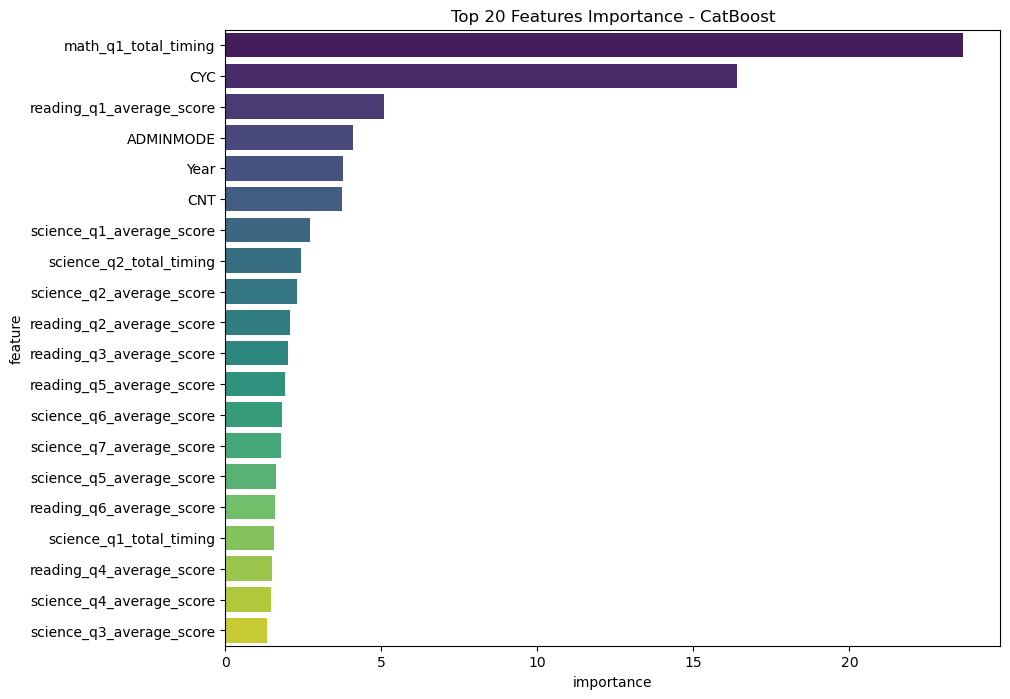

In [15]:
# =============================================================================
# IMPLEMENTATION CATBOOST
# =============================================================================

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


X_cb = X_train_new.copy()

cat_features = X_cb.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_cb.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Nombre de features catégorielles : {len(cat_features)}")
print(f"Nombre de features numériques : {len(num_features)}")

for col in cat_features:
    X_cb[col] = X_cb[col].fillna("MISSING").astype(str)


target_col = y_train.columns[1]
y_cb = y_train[target_col]

X_cb = X_cb.loc[y_cb.index]

X_tr, X_val, y_tr, y_val = train_test_split(X_cb, y_cb, test_size=0.2, random_state=42)

print(f"Train shape: {X_tr.shape}, Val shape: {X_val.shape}")


train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

model_cb = CatBoostRegressor(
    iterations=2000,          
    learning_rate=0.03,       
    depth=10,                  
    loss_function='RMSE',
    eval_metric='R2',         
    random_seed=42,
    verbose=100,              
    early_stopping_rounds=75  
)

model_cb.fit(train_pool, eval_set=val_pool)

y_pred_val = model_cb.predict(X_val)
score_r2 = r2_score(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

print(f"R² sur validation : {score_r2:.4f}")
print(f"RMSE sur validation : {rmse:.4f}")

feature_importances = model_cb.get_feature_importance(train_pool)
feature_names = X_tr.columns
fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
fi_df = fi_df.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
plt.title('Top 20 Features Importance - CatBoost')
plt.show()

In [16]:
# =============================================================================
# 7. PRÉDICTION FINALE SUR X_TEST
# =============================================================================

X_test = pd.read_csv('X_test.csv', low_memory=False)
X_test_final = X_test.reindex(columns=X_cb.columns)

print(f"Dimensions X_test original : {X_test.shape}")
print(f"Dimensions X_test aligné   : {X_test_final.shape}")

for col in cat_features:
    if col in X_test_final.columns:
        X_test_final[col] = X_test_final[col].fillna("MISSING").astype(str)


y_test_pred = model_cb.predict(X_test_final)


Dimensions X_test original : (586044, 307)
Dimensions X_test aligné   : (586044, 82)


In [17]:
submission_f = pd.DataFrame()

submission_f['Unnamed: 0'] = X_test['Unnamed: 0']
submission_f['MathScore'] = y_test_pred

submission_f['MathScore'] = submission_f['MathScore'].clip(lower=0, upper=1000)


In [18]:
submission_f.columns.values[0] = "ID"

In [ ]:
# Sauvegarde
submission_file = 'y_test_prediction_catboost_3.csv' # Modifier le nom du fichier
submission_f.to_csv(submission_file, index=False)

print(f"Prédictions sauvegardées dans : {submission_file}")
display(submission_f.head())

Prédictions sauvegardées dans : y_test_prediction_catboost_3.csv


,ID,MathScore
0,412660,142.609908
1,554658,88.199554
2,937138,0.000000
3,752986,209.949760
4,1084508,133.155616


In [ ]:
### Some others test have been done on other notebook to compare various models: 

"""
X = X_train_new.iloc[:, 1:]
y = y_train['MathScore']

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse=False pour éviter les problèmes de mémoire si possible, sinon True
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1), # n_jobs=-1 pour utiliser tous les coeurs
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0) 
    
}
"""

In [32]:
df = pd.read_csv('X_train.csv', low_memory=False, nrows=1000)
df = df.reindex(columns=X_cb.columns)

Nombre de features catégorielles : 3
Nombre de features numériques : 79
Train shape: (800, 82), Val shape: (200, 82)
0:	learn: 0.0294736	test: 0.0238254	best: 0.0238254 (0)	total: 150ms	remaining: 5m


100:	learn: 0.8168636	test: 0.6095857	best: 0.6095857 (100)	total: 16.8s	remaining: 5m 15s
200:	learn: 0.9215401	test: 0.6403550	best: 0.6404171 (199)	total: 33.4s	remaining: 4m 58s
300:	learn: 0.9573050	test: 0.6455980	best: 0.6455980 (300)	total: 50.4s	remaining: 4m 44s
400:	learn: 0.9739285	test: 0.6470574	best: 0.6471677 (399)	total: 1m 7s	remaining: 4m 28s
500:	learn: 0.9836913	test: 0.6461287	best: 0.6473087 (443)	total: 1m 24s	remaining: 4m 12s
Stopped by overfitting detector  (75 iterations wait)

bestTest = 0.6473087448
bestIteration = 443

Shrink model to first 444 iterations.
R² sur validation : 0.6473
RMSE sur validation : 69.4920


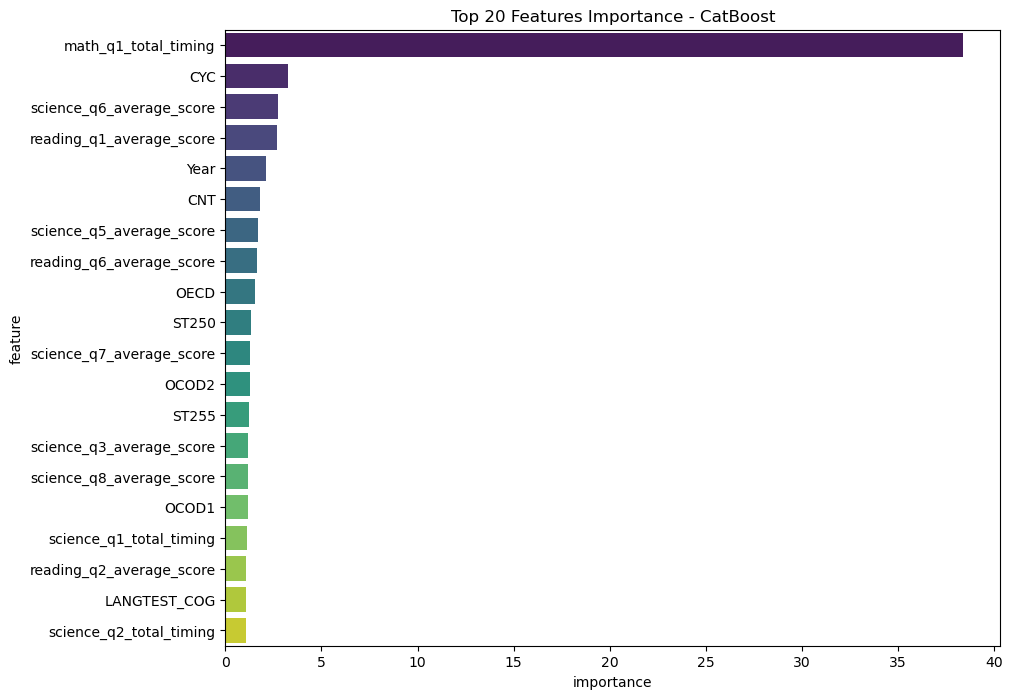

In [33]:
X_cb_2 = df.copy()

cat_features_2 = X_cb_2.select_dtypes(include=['object', 'category']).columns.tolist()
num_features_2 = X_cb_2.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Nombre de features catégorielles : {len(cat_features_2)}")
print(f"Nombre de features numériques : {len(num_features_2)}")

for col in cat_features:
    X_cb_2[col] = X_cb_2[col].fillna("MISSING").astype(str)


target_col_2 = y_train.columns[1]
y_cb_2 = y_train[target_col_2]

common_index = X_cb_2.index.intersection(y_cb_2.index)
X_cb_2 = X_cb_2.loc[common_index]
y_cb_2 = y_cb_2.loc[common_index]

X_tr_2, X_val_2, y_tr_2, y_val_2 = train_test_split(X_cb_2, y_cb_2, test_size=0.2, random_state=42)

print(f"Train shape: {X_tr_2.shape}, Val shape: {X_val_2.shape}")


train_pool_2 = Pool(X_tr_2, y_tr_2, cat_features=cat_features_2)
val_pool_2 = Pool(X_val_2, y_val_2, cat_features=cat_features_2)

model_cb_2 = CatBoostRegressor(
    iterations=2000,          
    learning_rate=0.03,       
    depth=10,                  
    loss_function='RMSE',
    eval_metric='R2',         
    random_seed=42,
    verbose=100,              
    early_stopping_rounds=75  
)

model_cb_2.fit(train_pool_2, eval_set=val_pool_2)

y_pred_val_2 = model_cb_2.predict(X_val_2)
score_r2_2 = r2_score(y_val_2, y_pred_val_2)
rmse_2 = np.sqrt(mean_squared_error(y_val_2, y_pred_val_2))

print(f"R² sur validation : {score_r2_2:.4f}")
print(f"RMSE sur validation : {rmse_2:.4f}")

feature_importances_2 = model_cb_2.get_feature_importance(train_pool_2)
feature_names_2 = X_tr_2.columns
fi_df_2 = pd.DataFrame({'feature': feature_names_2, 'importance': feature_importances_2})
fi_df_2 = fi_df_2.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=fi_df_2, palette='viridis')
plt.title('Top 20 Features Importance - CatBoost')
plt.show()

In [35]:
X_test_2 = pd.read_csv('X_test.csv', low_memory=False)
X_test_final_2 = X_test_2.reindex(columns=X_cb_2.columns)

print(f"Dimensions X_test original : {X_test_2.shape}")
print(f"Dimensions X_test aligné   : {X_test_final_2.shape}")

for col in cat_features:
    if col in X_test_final_2.columns:
        X_test_final_2[col] = X_test_final_2[col].fillna("MISSING").astype(str)


y_test_pred_2 = model_cb_2.predict(X_test_final_2)

Dimensions X_test original : (586044, 307)
Dimensions X_test aligné   : (586044, 82)


In [36]:
submission_f_2 = pd.DataFrame()

submission_f_2['Unnamed: 0'] = X_test_2['Unnamed: 0']
submission_f_2['MathScore'] = y_test_pred_2

submission_f_2['MathScore'] = submission_f_2['MathScore'].clip(lower=0, upper=1000)

submission_f_2.columns.values[0] = "ID"

# Sauvegarde
submission_file_2 = 'y_test_prediction_catboost_small.csv' # Modifier le nom du fichier
submission_f_2.to_csv(submission_file_2, index=False)

print(f"Prédictions sauvegardées dans : {submission_file_2}")
display(submission_f_2.head())

Prédictions sauvegardées dans : y_test_prediction_catboost_small.csv


,ID,MathScore
0,412660,86.810102
1,554658,87.815065
2,937138,21.960884
3,752986,237.680382
4,1084508,109.987520
